# Verificación de supuestos


Los supuestos son indispensables en el modelo de regresión pues garantizan la veracidad de las estimaciones, intervalos de confianza y pruebas de hipótesis hechas.

Supuestos del modelo de regresión:

- Homocedasticidad (No heterocedasticidad)
- Linealidad (No multicolinealidad)
- Normalidad de los errores.
- Independencia de los errores/observaciones.

Será de interés verificar que se cumplan (o casi) estos supuestos realizando un análisis de los residuales. A continuación mostraremos algunas herramientas computacionales de utilidad al momento de realizar la validación de supuestos.

**"No afirmaremos que se cumplen los supuestos, solo no hay evidencia para decir que no se cumplen."**



# Ejemplo

Seguiremos trabajando con un conjunto de datos conocido.

In [2]:
datos <-  data.frame(mtcars)

# prepro
datos$am <- factor(datos$am, levels = c(0,1))
datos$vs <- factor(datos$vs, levels = c(0,1))
datos$cyl <- factor(datos$cyl, levels = c(4,6,8))
datos$gear <- factor(datos$gear, levels= c(3,4,5))
datos$carb <- factor(datos$carb, levels= c(1,2,3,4,6,8))


modelo1<- lm(mpg ~ wt + hp + cyl, data = datos)

summary(modelo1)


Call:
lm(formula = mpg ~ wt + hp + cyl, data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.2612 -1.0320 -0.3210  0.9281  5.3947 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 35.84600    2.04102  17.563 2.67e-16 ***
wt          -3.18140    0.71960  -4.421 0.000144 ***
hp          -0.02312    0.01195  -1.934 0.063613 .  
cyl6        -3.35902    1.40167  -2.396 0.023747 *  
cyl8        -3.18588    2.17048  -1.468 0.153705    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.44 on 27 degrees of freedom
Multiple R-squared:  0.8572,	Adjusted R-squared:  0.8361 
F-statistic: 40.53 on 4 and 27 DF,  p-value: 4.869e-11


Procederemos con la verificación de supuestos con ayuda de gráficas y algunas pruebas de hipótesis. Esta evaluación puede ser subjetiva, por lo que es importante definir que no existe una regla. Lo ideal es identificar las características que no son deseables en un gráfico y tomarlo como referencia.



## Diagnóstico general


Al aplicar la función `plot()` a un modelo de regresión, nos muestra algunas gráficas generales de utilidad.

1. **Residuals vs Fitted Plot**

Esta gráfica evalúa el supuesto de linealidad y la ausencia de patrones en los residuos.  

Caso ideal:

- Los residuos deben mostrarse "aleatoriamente" alrededor de la línea horizontal en 0.
- No debe observarse estructura, curvatura ni tendencia.

Indicios de incumplimiento:

- Curvaturas marcadas, que indican falta de linealidad.
- Forma de embudo, asociada con heterocedasticidad.
- Patrones visibles que sugieren variables omitidas.

2. **Normal Q-Q Plot**

Esta gráfica evalúa el supuesto de normalidad en los residuos. 

Caso ideal:

- Los puntos deben alinearse aproximadamente sobre la recta identidad.
- Pequeñas desviaciones en las colas son "aceptables".

Indicios de incumplimiento:

- Colas alejadas de la recta identidad, que indican colas pesadas.
- Asimetría notoria.
- Curvatura en forma de “S”, típica de distribuciones no normales.

3. **Scale-Location Plot**

Esta gráfica evalúa el supuesto de homocedasticidad, es decir, que la varianza de los residuos sea constante.  

Caso ideal:

- Los puntos deben formar una banda relativamente "uniforme".
- La curva suavizada debe permanecer casi horizontal.

Indicios de incumplimiento:

- Estructuras de embudo, asociadas con varianza creciente o decreciente.
- Tendencias ascendentes o descendentes en la curva roja.

4. **Residuals vs Leverage Plot**

Esta gráfica permite identificar observaciones influyentes resaltando las observaciones que tienen una distancia de Cook "grande".

La distancia de Cook es una medida que indica cuánto cambiarían los coeficientes de un modelo de regresión si elimináramos una observación específica, por lo que ayuda a identificar valores "influyentes".


Caso ideal:

- La mayoría de los puntos deben ubicarse lejos de las curvas de Cook.

Indicios de incumplimiento:

- Puntos cercanos o por fuera de las curvas de Cook.
- Combinaciones de residuos grandes con leverage alto.



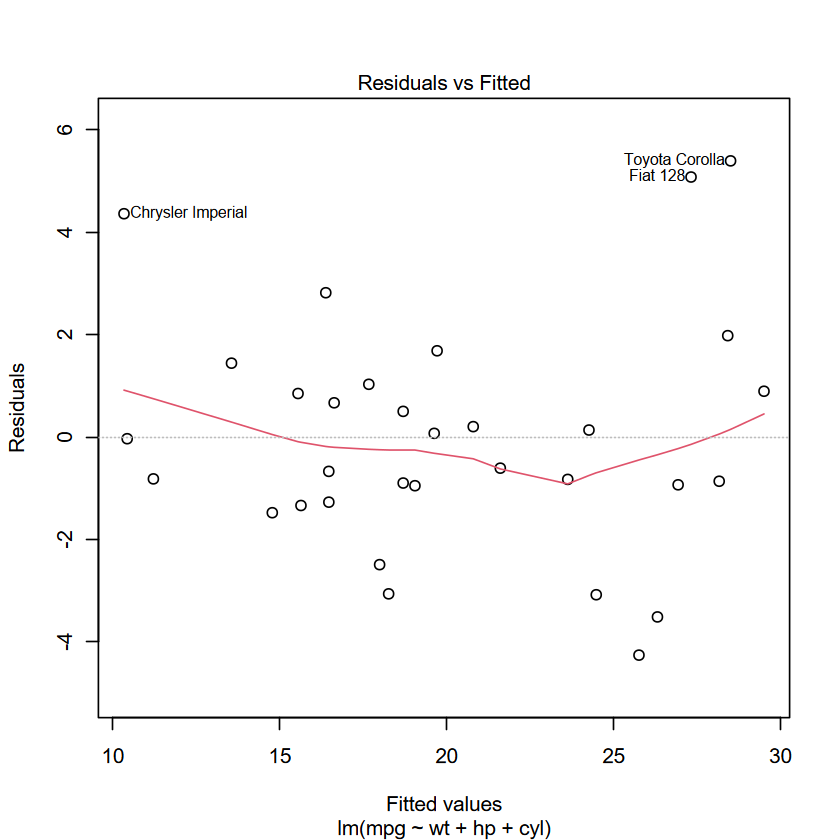

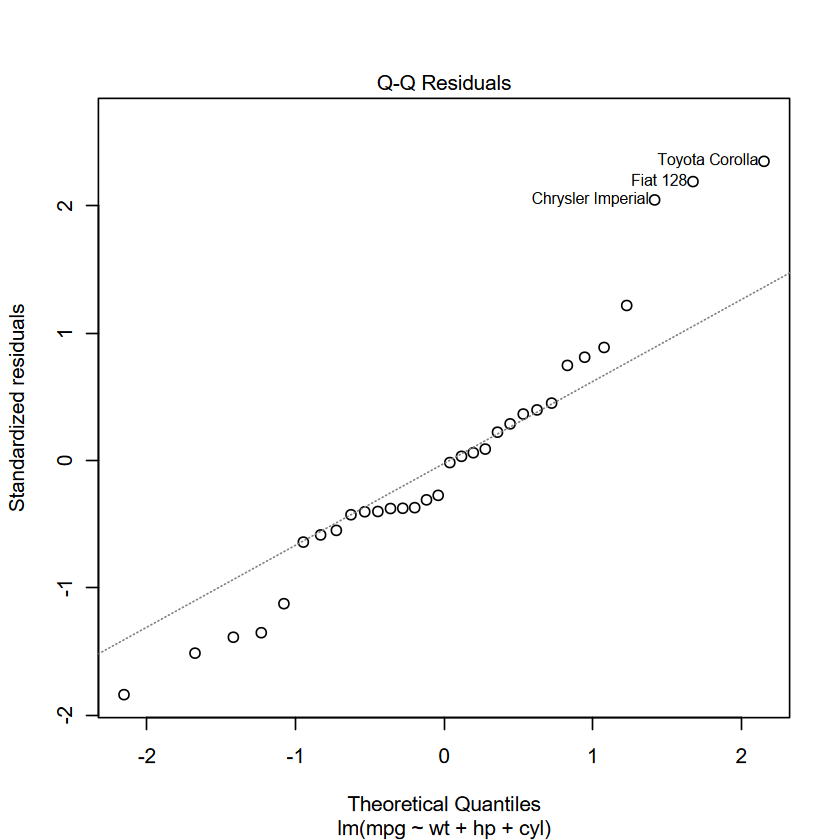

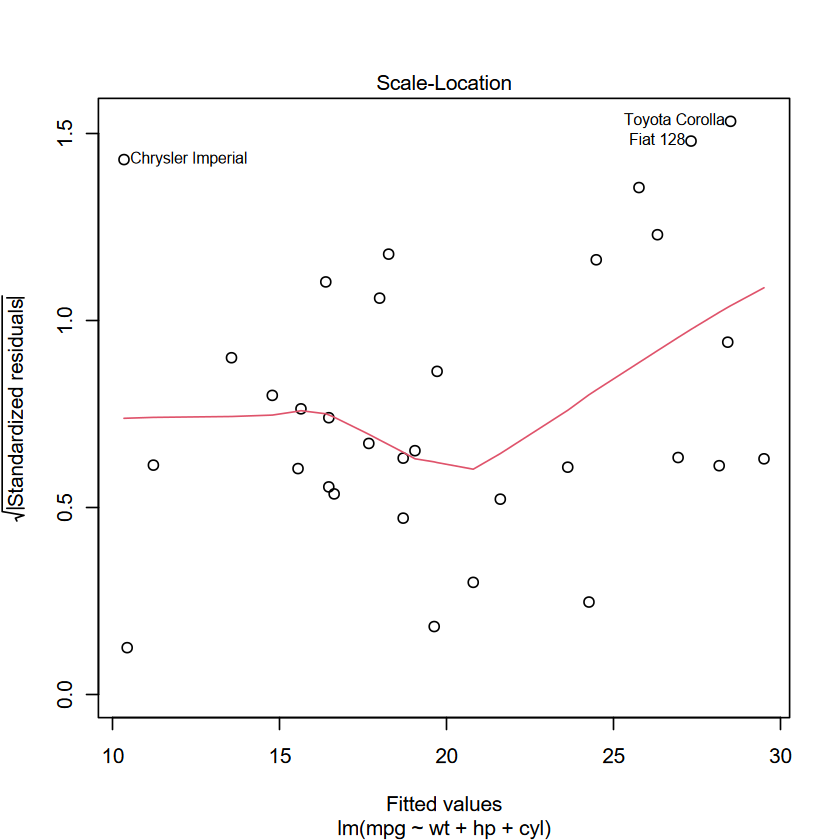

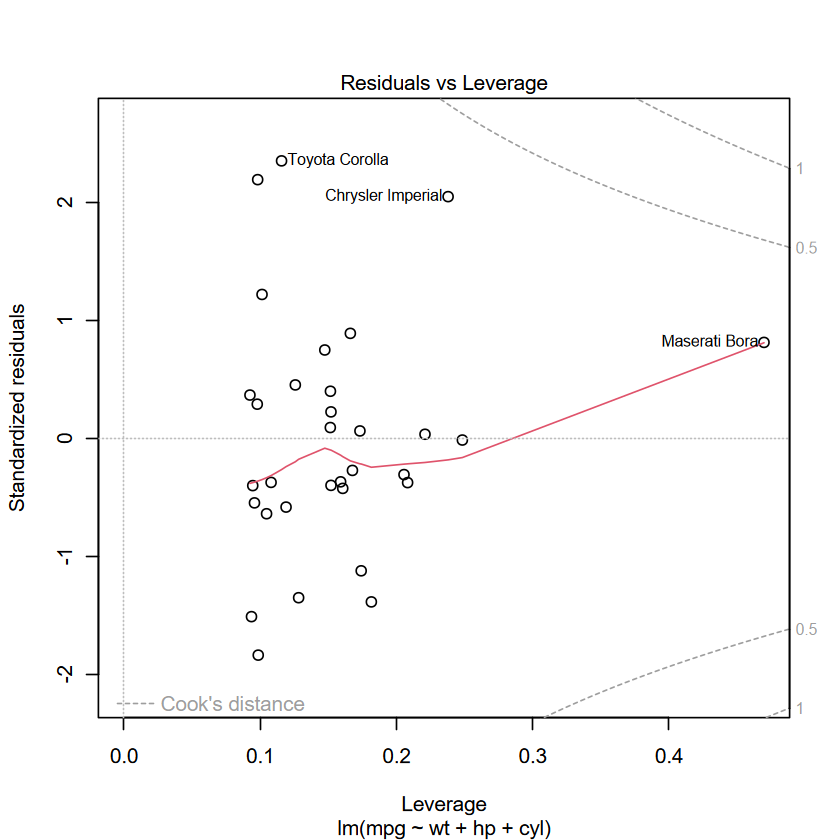

In [8]:
plot(modelo1)


Otra alternativa es la libreria `ggResidpanel` con la función `resid_panel`. 

Interpretando las gráficas nuevas:


1. Index Plot

Esta gráfica muestra los residuos en el orden en que aparecen en el conjunto de datos. Ayuda a verificar si los errores se comportan de manera aleatoria (sin estructura o patrón).

Caso ideal:
- Los residuos deben oscilar alrededor de cero sin mostrar tendencias, ciclos ni agrupamientos claros.
- No deben observarse patrones repetitivos ni bloques con residuos predominantemente positivos o negativos.

Indicios de incumplimiento:
- Tendencias ascendentes o descendentes.
- Agrupamientos visibles, que indican de correlación entre errores.
- Segmentos largos con residuos de un mismo signo, lo cual puede sugerir dependencia.

2. Residual Plot 

Esta gráfica muestra los residuos en función de los valores ajustados por el modelo. Ayuda a evaluar el supuesto de linealidad.

Caso ideal:
- Los puntos deben formar una nube dispersa sin estructura definida.
- Los residuos deben distribuirse de manera uniforme alrededor de cero para todos los valores ajustados.

Indicios de incumplimiento:
- Curvas sugerentes de relaciones no lineales.
- Bandas que indiquen dependencia entre la magnitud del residuo y el valor ajustado.
- Estructuras reconocibles que sugieran ausencia de variables importantes.

3. Response vs Predicted

Esta gráfica compara los valores observados de la variable respuesta con los valores predichos por el modelo. Ayuda a evaluar la calidad general del ajuste y detectar posibles sesgos.

Caso ideal:
- Los puntos deben seguir el modelo.
- Las desviaciones deben ser pequeñas y sin patrón definido.

Indicios de incumplimiento:
- Desviaciones visibles, lo que indica que el modelo subestima o sobreestima ciertos rangos.
- Acumulación de puntos por encima o por debajo de la recta.
- Patrones de forma no lineal que sugieren falta de linealidad o efectos no modelados.





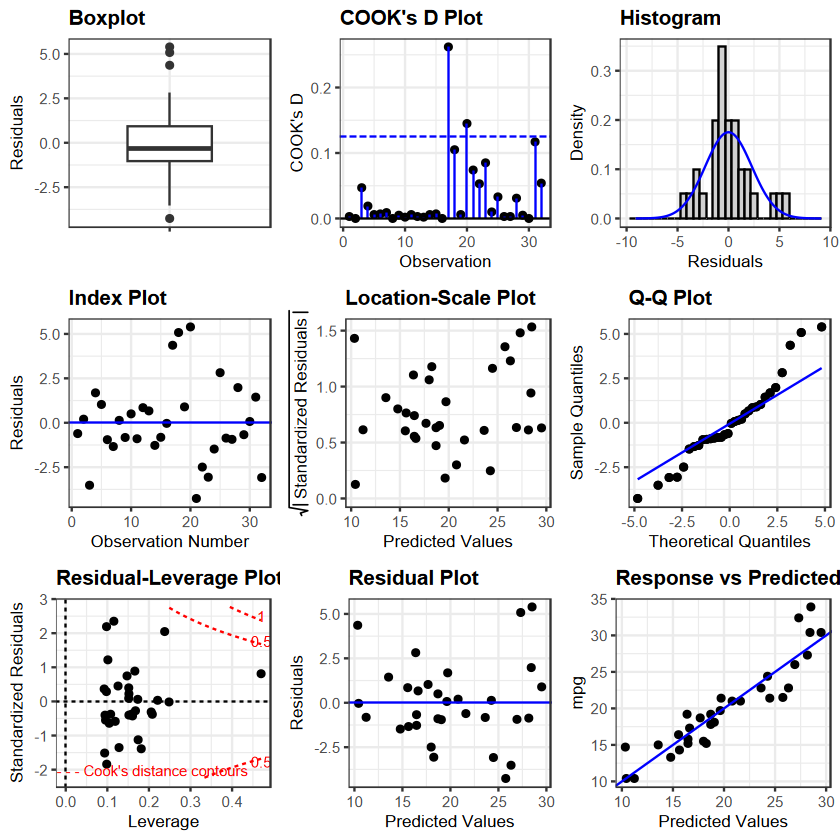

In [6]:
library(ggResidpanel)

resid_panel(modelo1,plots = c("boxplot",
"cookd",
"hist",
"index",
"ls",
"qq",
"lev",
"resid",
"yvp"))

La función `resid_compare()` también permite visualizar las gráficas de diagnóstico de varios modelos para comparar entre ellos.

Realizaremos una comparación con un modelo inútil, que solo considera a las variables categóricas `cyl` y `am`, se puede adelantar que las gráficas de este presentarán indicios de falta de variables relevantes dentro del modelo. 

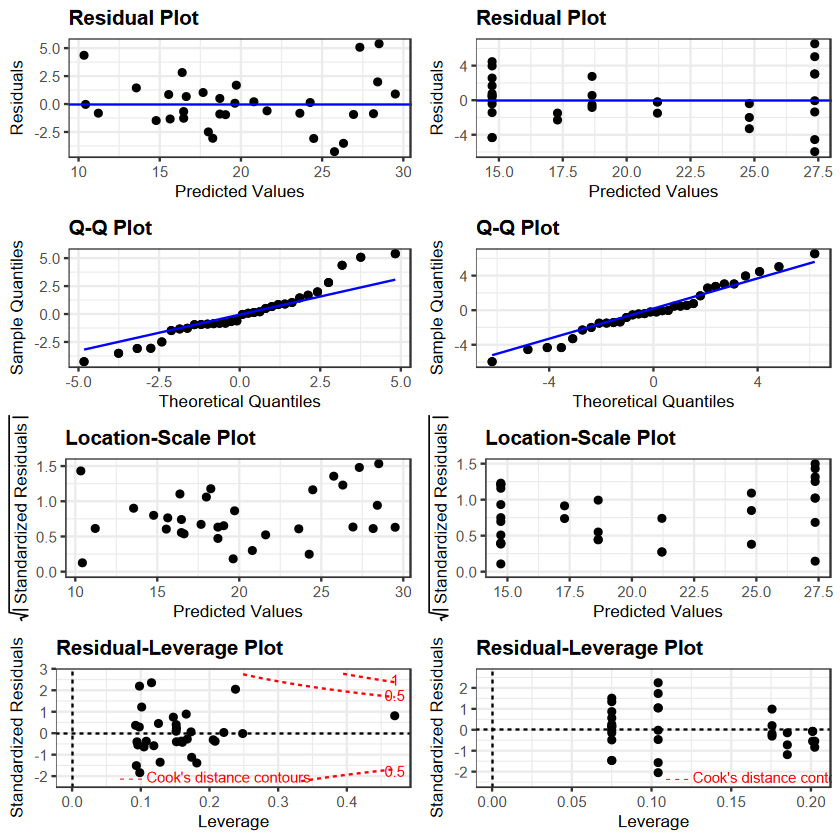

In [9]:
modelo2<- lm(mpg ~ cyl + am, data = datos)

resid_compare(models = list(modelo1, modelo2),
              plots = c("R"),
              title.opt = TRUE)


## Homocedasticidad


Las pruebas de hipótesis usadas para verificar este supuesto tienen la forma:

$$
H_{0}: \text{Varianza constante} \quad H_{1}: \text{Heterocedasticidad}
$$

In [9]:
library(lmtest)

bptest(modelo1)

Cargando paquete requerido: zoo


Adjuntando el paquete: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  modelo1
BP = 6.1707, df = 4, p-value = 0.1868


In [10]:
library(car)

ncvTest(modelo1)

Cargando paquete requerido: carData



Non-constant Variance Score Test 
Variance formula: ~ fitted.values 
Chisquare = 3.374465, Df = 1, p = 0.066214

## Linealidad

## Normalidad de los errores


## Independencia/ Covarianza cero de los errores

# Arreglando la verificación de supuestos

Luego de ajustar un modelo de regresión lineal, las gráficas de diagnóstico pueden mostrar evidencia en contra del cumplimiento de los supuestos. Afortunadamente existen técnicas que permiten "corregir" estas violaciones mediante transformaciones de la variable respuesta, transformaciones de los predictores.

**En la práctica, los problemas más comunes son la falta de linealidad, la ausencia de normalidad de los residuos y la heterocedasticidad**, y estas transformaciones ayudarán a mitigar la evidencia en contra de estos supuestos.







## Transformaciones Box-Cox

La transformación Box–Cox se aplica a la variable respuesta. Su propósito es "reducir" la varianza y aproximar la distribución de los residuos a la distribución Normal. **Es útil cuando el supuesto de homocedasticidad no se cumple o cuando los residuos presentan asimetría importante.**

La transformación está definida como:

$$
g(y) = y^{(\lambda)} =
\begin{cases}
\dfrac{y^\lambda - 1}{\lambda}, & \lambda \neq 0 \\
\ln(y), & \lambda = 0
\end{cases}
$$

Donde $\lambda$ se estima mediante Máxima Verosimilitud. Encuentra el valor que hace más verosímil observar un modelo lineal, normal con esperanza lineal y varianza constante. Notemos que $\lambda$ indica que no se requiere una transformación.

**Se requiere que todas las observaciones de la variable sean positivas, si no, trasladamos las observaciones para que todas sean positivas.**

**Si $\lambda = 0$, se debe tener cuidadao con la interpretacion.**





En la paqueteria `car`, se implementa la estimación de $\lambda$.


In [ ]:
library(car) #necesaria

#primer renglon estimaciones
# segundo ph basta con transfomacion log?
# tercero ph no hace falta transformar?


summary(powerTransform(modelo1)) 

summary(powerTransform(modelo2)) 



bcPower Transformation to Normality 
   Est Power Rounded Pwr Wald Lwr Bnd Wald Upr Bnd
Y1    0.0509           0      -0.5364       0.6381

Likelihood ratio test that transformation parameter is equal to 0
 (log transformation)
                             LRT df    pval
LR test, lambda = (0) 0.02885179  1 0.86512

Likelihood ratio test that no transformation is needed
                          LRT df      pval
LR test, lambda = (1) 8.90628  1 0.0028419

bcPower Transformation to Normality 
   Est Power Rounded Pwr Wald Lwr Bnd Wald Upr Bnd
Y1    0.3673           1      -0.3466       1.0812

Likelihood ratio test that transformation parameter is equal to 0
 (log transformation)
                           LRT df   pval
LR test, lambda = (0) 1.014619  1 0.3138

Likelihood ratio test that no transformation is needed
                           LRT df     pval
LR test, lambda = (1) 2.916477  1 0.087679

### Observación

En el modelo de regresión lineal clásica se modela $\mathbb{E}(Y \mid X)$, sin embargo, cuando se aplica la transformación Box--Cox, el modelo deja de estar formulado en términos de la media y pasa a describir la mediana de la variable respuesta transformada. 

Se puede demostrar que:

$$ 
Med(y;x) = g^{−1}(Med(y^{\lambda};x)).

$$


## Transformaciones Box-Tidwell

La transformación Box–Tidwell se utiliza para transformar predictores continuos con el objetivo de mejorar la linealidad en la relación entre la variable respuesta y las covariables. 


La forma de la transformación para un predictor continuo $x$ es:

$$
x^{(\theta)} = x^{\theta}
$$

Donde $\theta$ se estima mediante Máxima Verosimilitud.

Supuestos que ayuda a corregir:

- Falta de linealidad entre predictores continuos y la variable respuesta.
- Tendencias o curvaturas observadas en los residuos contra valores ajustados.
- Problemas de especificación funcional del modelo.



In [ ]:
summary(datos)


# estimacion de lambda

# H0: lambda_j =1    vs   H1: lamnda =! 1 

# prueba simultanea sobre todas las variables

boxTidwell(mpg ~hp+wt , data=datos)


      mpg        cyl         disp             hp             drat      
 Min.   :10.40   4:11   Min.   : 71.1   Min.   : 52.0   Min.   :2.760  
 1st Qu.:15.43   6: 7   1st Qu.:120.8   1st Qu.: 96.5   1st Qu.:3.080  
 Median :19.20   8:14   Median :196.3   Median :123.0   Median :3.695  
 Mean   :20.09          Mean   :230.7   Mean   :146.7   Mean   :3.597  
 3rd Qu.:22.80          3rd Qu.:326.0   3rd Qu.:180.0   3rd Qu.:3.920  
 Max.   :33.90          Max.   :472.0   Max.   :335.0   Max.   :4.930  
       wt             qsec       vs     am     gear   carb  
 Min.   :1.513   Min.   :14.50   0:18   0:19   3:15   1: 7  
 1st Qu.:2.581   1st Qu.:16.89   1:14   1:13   4:12   2:10  
 Median :3.325   Median :17.71                 5: 5   3: 3  
 Mean   :3.217   Mean   :17.85                        4:10  
 3rd Qu.:3.610   3rd Qu.:18.90                        6: 1  
 Max.   :5.424   Max.   :22.90                        8: 1  

   MLE of lambda Score Statistic (t) Pr(>|t|)  
hp      -0.56824              2.3741  0.02496 *
wt      -0.41743              2.7228  0.01120 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

iterations =  6 

Score test for null hypothesis that all lambdas = 1:
F = 8.8089, df = 2 and 27, Pr(>F) = 0.001135
